# Декодирование DTMF сигнала с помощью алгоритма Герцеля

## Задача
Декодировать DTMF сигнал из файла `DTMF_Lab12.wav` и восстановить исходную последовательность цифр и управляющих клавиш.

## Параметры сигнала
- Частота дискретизации: Fd = 44100 Hz
- Формат: 16 Bit, Mono, PCM
- Длина каждого элемента: 200 мс
- Пауза между элементами: 100 мс

## Алгоритм Герцеля
Для вычисления компоненты спектра X(k) используется:
- α = 2πk/N
- k = [f * N / Fd], где f - частота DTMF, Fd - частота дискретизации, N - длина ДПФ


In [2]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10


## Загрузка аудио файла


In [3]:
audio_file = 'DTMF_Lab12.wav'
x, Fd = sf.read(audio_file)

print(f"Частота дискретизации: Fd = {Fd} Hz")
print(f"Длина сигнала: {len(x)} отсчетов")
print(f"Длительность: {len(x) / Fd:.2f} секунд")
print(f"Тип данных: {x.dtype}")
print(f"Форма сигнала: {x.shape}")

# Если стерео, берем только один канал
if len(x.shape) > 1:
    x = x[:, 0]

# Нормализация
x = x.astype(np.float64)


Частота дискретизации: Fd = 44100 Hz
Длина сигнала: 211680 отсчетов
Длительность: 4.80 секунд
Тип данных: float64
Форма сигнала: (211680,)


## Визуализация сигнала


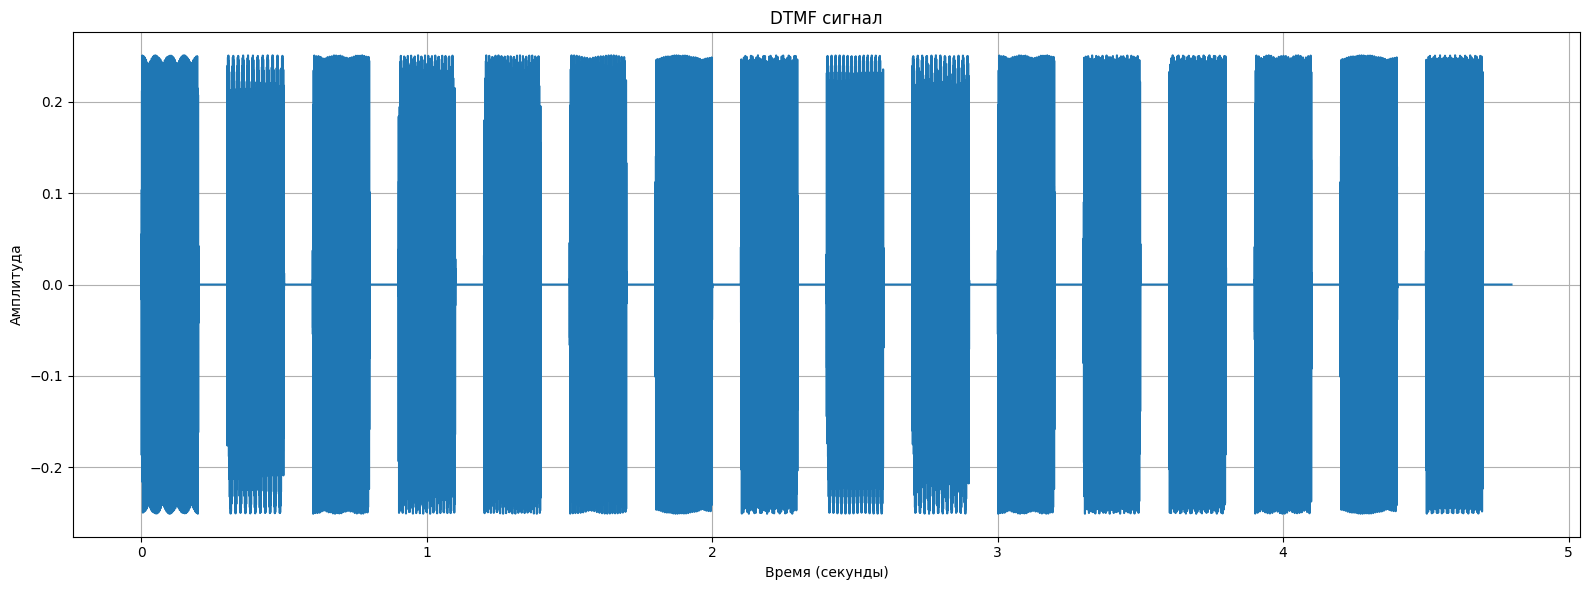

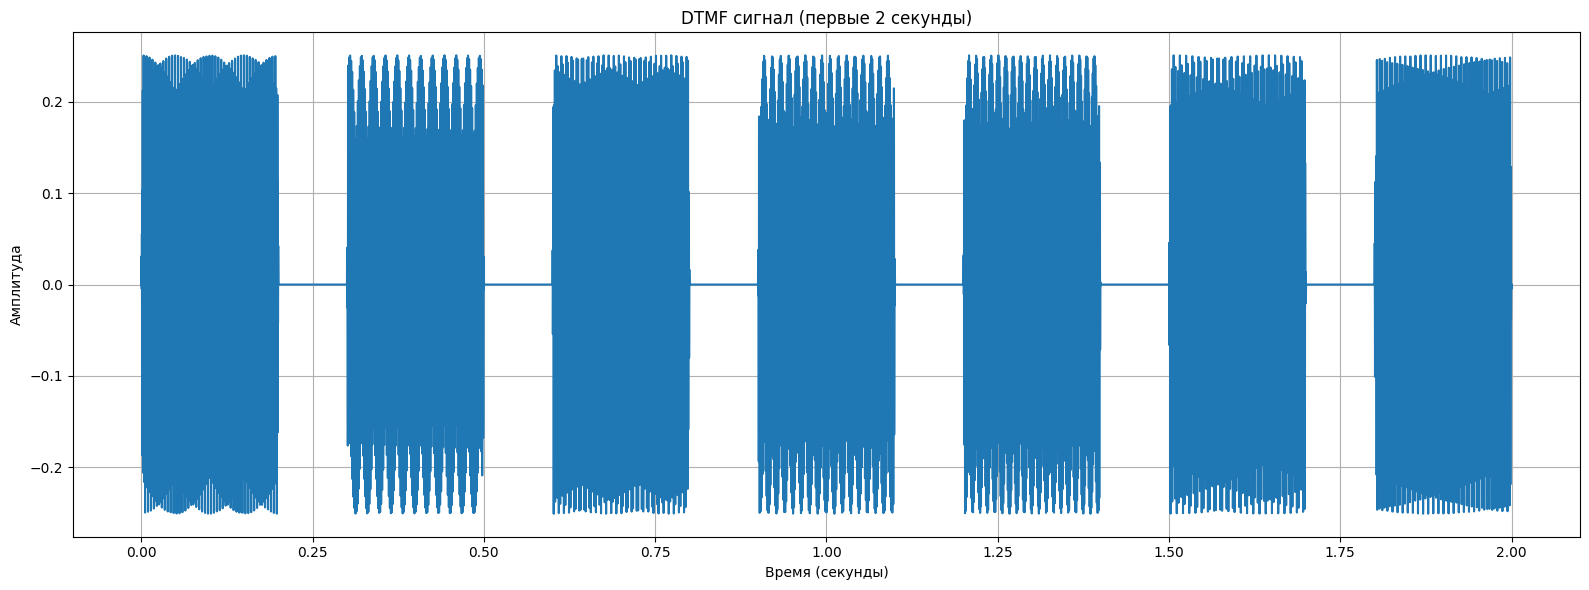

In [ ]:
time_axis = np.arange(len(x)) / Fd

plt.figure(figsize=(16, 6))
plt.plot(time_axis, x)
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')
plt.title('DTMF сигнал')
plt.grid(True)
plt.tight_layout()
plt.show()

# Визуализация первых 2 секунд для детального просмотра
plt.figure(figsize=(16, 6))
samples_to_show = min(2 * Fd, len(x))
plt.plot(time_axis[:samples_to_show], x[:samples_to_show])
plt.xlabel('Время (секунды)')
plt.ylabel('Амплитуда')
plt.title('DTMF сигнал (первые 2 секунды)')
plt.grid(True)
plt.tight_layout()
plt.show()


## Определение DTMF частот

DTMF использует 8 частот:
- Низкие частоты (строки): 697, 770, 852, 941 Hz
- Высокие частоты (столбцы): 1209, 1336, 1477, 1633 Hz


In [13]:
# DTMF частоты
low_freqs = [697, 770, 852, 941]  # Строки
high_freqs = [1209, 1336, 1477, 1633]  # Столбцы

dtmf_map = {
    (697, 1209): '1',
    (697, 1336): '2',
    (697, 1477): '3',
    (697, 1633): 'A',
    (770, 1209): '4',
    (770, 1336): '5',
    (770, 1477): '6',
    (770, 1633): 'B',
    (852, 1209): '7',
    (852, 1336): '8',
    (852, 1477): '9',
    (852, 1633): 'C',
    (941, 1209): '*',
    (941, 1336): '0',
    (941, 1477): '#',
    (941, 1633): 'D'
}


## Реализация алгоритма Герцеля

Алгоритм Герцеля вычисляет одну спектральную компоненту X(k) для заданной частоты.

Для вычисления используется:
- k = [f * N / Fd] - номер компоненты спектра
- α = 2πk/N


In [ ]:
def goertzel(x, f, Fd, N):
    """
    Алгоритм Герцеля для вычисления амплитуды спектральной компоненты
    
    Параметры:
    x - входной сигнал
    f - частота для анализа
    Fd - частота дискретизации
    N - длина ДПФ (длина окна анализа)
    
    Возвращает:
    magnitude - амплитуда спектральной компоненты
    """
    k = int(round(f * N / Fd))
    
    alpha = 2 * np.pi * k / N
    
    # Коэффициенты для фильтра Герцеля
    w = 2 * np.cos(alpha)
    
    q0 = 0
    q1 = 0
    q2 = 0
    
    # Проход по сигналу
    for n in range(N):
        q0 = w * q1 - q2 + x[n]
        q2 = q1
        q1 = q0
    
    # Вычисление амплитуды
    real_part = q1 - q2 * np.cos(alpha)
    imag_part = q2 * np.sin(alpha)
    magnitude = np.sqrt(real_part**2 + imag_part**2)
    
    return magnitude


## Разделение сигнала на сегменты

Каждый элемент длится 200 мс, пауза между элементами - 100 мс.


Длина элемента: 200 мс = 8820 отсчетов
Длина паузы: 100 мс = 4410 отсчетов
Длина сегмента: 300 мс = 13230 отсчетов

Количество полных сегментов: 16


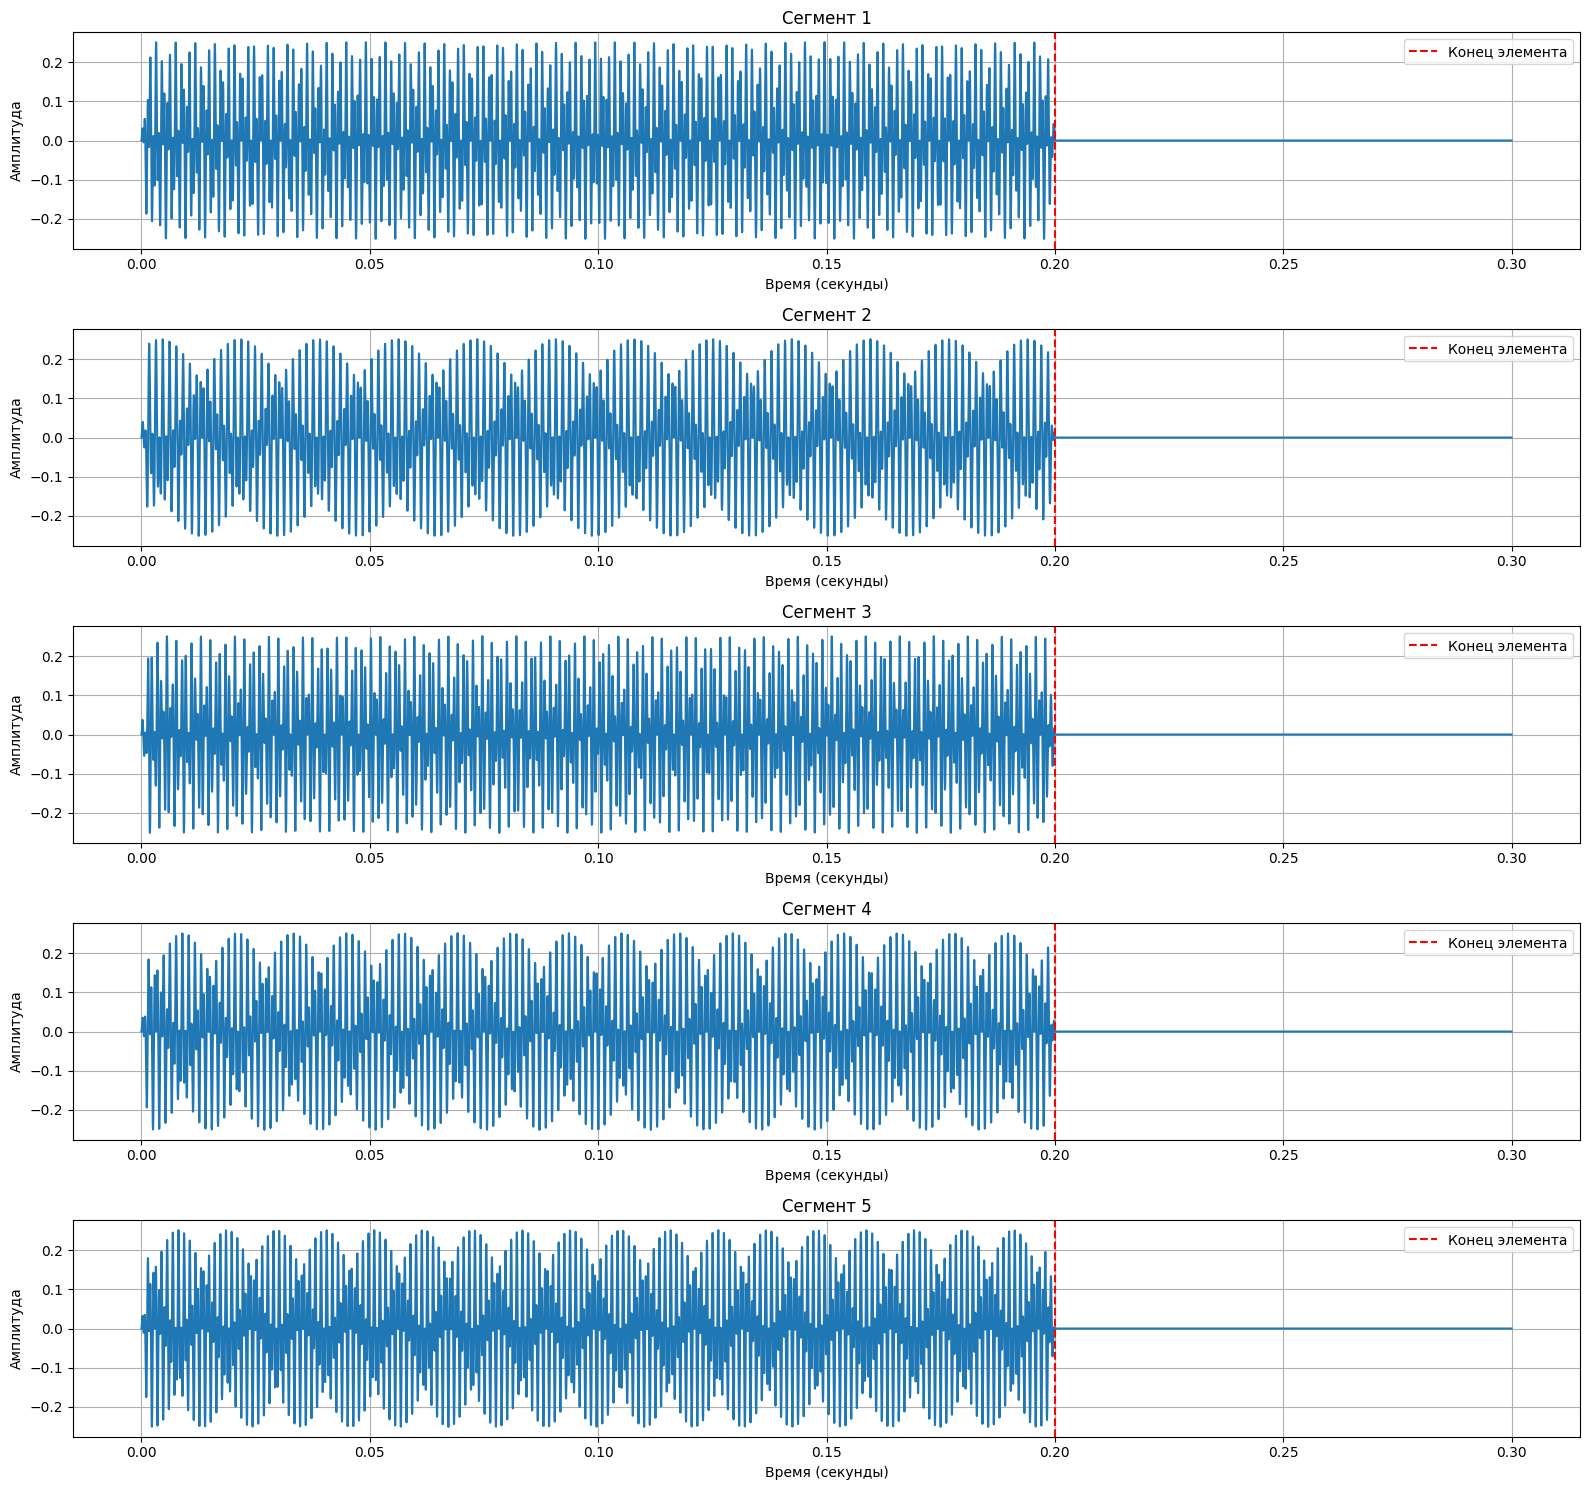

In [ ]:
# Параметры сегментации
element_duration = 0.200  # 200 мс
pause_duration = 0.100    # 100 мс
segment_duration = element_duration + pause_duration  # 300 мс

element_samples = int(element_duration * Fd)
pause_samples = int(pause_duration * Fd)
segment_samples = int(segment_duration * Fd)

print(f"Длина элемента: {element_duration * 1000:.0f} мс = {element_samples} отсчетов")
print(f"Длина паузы: {pause_duration * 1000:.0f} мс = {pause_samples} отсчетов")
print(f"Длина сегмента: {segment_duration * 1000:.0f} мс = {segment_samples} отсчетов")

num_segments = len(x) // segment_samples
print(f"\nКоличество полных сегментов: {num_segments}")

fig, axes = plt.subplots(min(5, num_segments), 1, figsize=(16, 3 * min(5, num_segments)))
if num_segments == 1:
    axes = [axes]

for i in range(min(5, num_segments)):
    start_idx = i * segment_samples
    end_idx = start_idx + segment_samples
    segment = x[start_idx:end_idx]
    time_seg = np.arange(len(segment)) / Fd
    
    axes[i].plot(time_seg, segment)
    axes[i].axvline(x=element_duration, color='r', linestyle='--', label='Конец элемента')
    axes[i].set_xlabel('Время (секунды)')
    axes[i].set_ylabel('Амплитуда')
    axes[i].set_title(f'Сегмент {i+1}')
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()


## Декодирование DTMF сигнала

Для каждого сегмента:
1. Берем только часть с элементом (200 мс)
2. Применяем алгоритм Герцеля для всех 8 DTMF частот
3. Определяем максимальные амплитуды для низких и высоких частот
4. Сопоставляем с таблицей DTMF


In [ ]:
# Длина окна для анализа (используем длину элемента)
N = element_samples

print(f"Длина окна анализа N = {N} отсчетов")
print(f"Соответствует {N/Fd*1000:.1f} мс")

print("\nВычисление k для каждой DTMF частоты:")
all_freqs = low_freqs + high_freqs
for f in all_freqs:
    k = int(round(f * N / Fd))
    print(f"f = {f:4d} Hz: k = {k:4d}, точная частота = {k * Fd / N:.2f} Hz")


Длина окна анализа N = 8820 отсчетов
Соответствует 200.0 мс

Вычисление k для каждой DTMF частоты:
f =  697 Hz: k =  139, точная частота = 695.00 Hz
f =  770 Hz: k =  154, точная частота = 770.00 Hz
f =  852 Hz: k =  170, точная частота = 850.00 Hz
f =  941 Hz: k =  188, точная частота = 940.00 Hz
f = 1209 Hz: k =  242, точная частота = 1210.00 Hz
f = 1336 Hz: k =  267, точная частота = 1335.00 Hz
f = 1477 Hz: k =  295, точная частота = 1475.00 Hz
f = 1633 Hz: k =  327, точная частота = 1635.00 Hz


In [ ]:
def decode_dtmf_segment(segment, Fd, N, low_freqs, high_freqs, dtmf_map, threshold_factor=0.3):
    """
    Декодирует один сегмент DTMF сигнала
    
    Параметры:
    segment - сегмент сигнала (только элемент, без паузы)
    Fd - частота дискретизации
    N - длина окна анализа
    low_freqs - список низких частот
    high_freqs - список высоких частот
    dtmf_map - словарь соответствия частот и символов
    threshold_factor - коэффициент для порога детекции (относительно максимума)
    
    Возвращает:
    symbol - декодированный символ или None
    """
    low_magnitudes = [goertzel(segment, f, Fd, N) for f in low_freqs]
    high_magnitudes = [goertzel(segment, f, Fd, N) for f in high_freqs]
    
    # Находим максимальные амплитуды
    max_low_idx = np.argmax(low_magnitudes)
    max_high_idx = np.argmax(high_magnitudes)
    
    max_low_mag = low_magnitudes[max_low_idx]
    max_high_mag = high_magnitudes[max_high_idx]
    
    # Порог детекции (относительно максимальной амплитуды среди всех частот)
    all_magnitudes = low_magnitudes + high_magnitudes
    max_all_mag = max(all_magnitudes)
    threshold = max_all_mag * threshold_factor
    
    if max_low_mag < threshold or max_high_mag < threshold:
        return None, low_magnitudes, high_magnitudes
    
    detected_low = low_freqs[max_low_idx]
    detected_high = high_freqs[max_high_idx]
    
    symbol = dtmf_map.get((detected_low, detected_high), None)
    
    return symbol, low_magnitudes, high_magnitudes


In [ ]:
decoded_sequence = []
all_low_mags = []
all_high_mags = []

for i in range(num_segments):
    start_idx = i * segment_samples
    end_idx = start_idx + element_samples  # Берем только элемент (200 мс)
    element_segment = x[start_idx:end_idx]
    
    symbol, low_mags, high_mags = decode_dtmf_segment(
        element_segment, Fd, N, low_freqs, high_freqs, dtmf_map
    )
    
    decoded_sequence.append(symbol)
    all_low_mags.append(low_mags)
    all_high_mags.append(high_mags)
    
    if symbol:
        print(f"Сегмент {i+1:2d}: '{symbol}' (низкая: {low_freqs[np.argmax(low_mags)]} Hz, "
              f"высокая: {high_freqs[np.argmax(high_mags)]} Hz)")
    else:
        print(f"Сегмент {i+1:2d}: не распознан")

print(f"\nВосстановленная последовательность: {''.join([s if s else '?' for s in decoded_sequence])}")


Сегмент  1: 'A' (низкая: 697 Hz, высокая: 1633 Hz)
Сегмент  2: '2' (низкая: 697 Hz, высокая: 1336 Hz)
Сегмент  3: '#' (низкая: 941 Hz, высокая: 1477 Hz)
Сегмент  4: '3' (низкая: 697 Hz, высокая: 1477 Hz)
Сегмент  5: 'B' (низкая: 770 Hz, высокая: 1633 Hz)
Сегмент  6: '4' (низкая: 770 Hz, высокая: 1209 Hz)
Сегмент  7: '*' (низкая: 941 Hz, высокая: 1209 Hz)
Сегмент  8: '5' (низкая: 770 Hz, высокая: 1336 Hz)
Сегмент  9: 'C' (низкая: 852 Hz, высокая: 1633 Hz)
Сегмент 10: '6' (низкая: 770 Hz, высокая: 1477 Hz)
Сегмент 11: '#' (низкая: 941 Hz, высокая: 1477 Hz)
Сегмент 12: '7' (низкая: 852 Hz, высокая: 1209 Hz)
Сегмент 13: 'D' (низкая: 941 Hz, высокая: 1633 Hz)
Сегмент 14: '8' (низкая: 852 Hz, высокая: 1336 Hz)
Сегмент 15: '*' (низкая: 941 Hz, высокая: 1209 Hz)
Сегмент 16: '9' (низкая: 852 Hz, высокая: 1477 Hz)

Восстановленная последовательность: A2#3B4*5C6#7D8*9


## Визуализация результатов декодирования


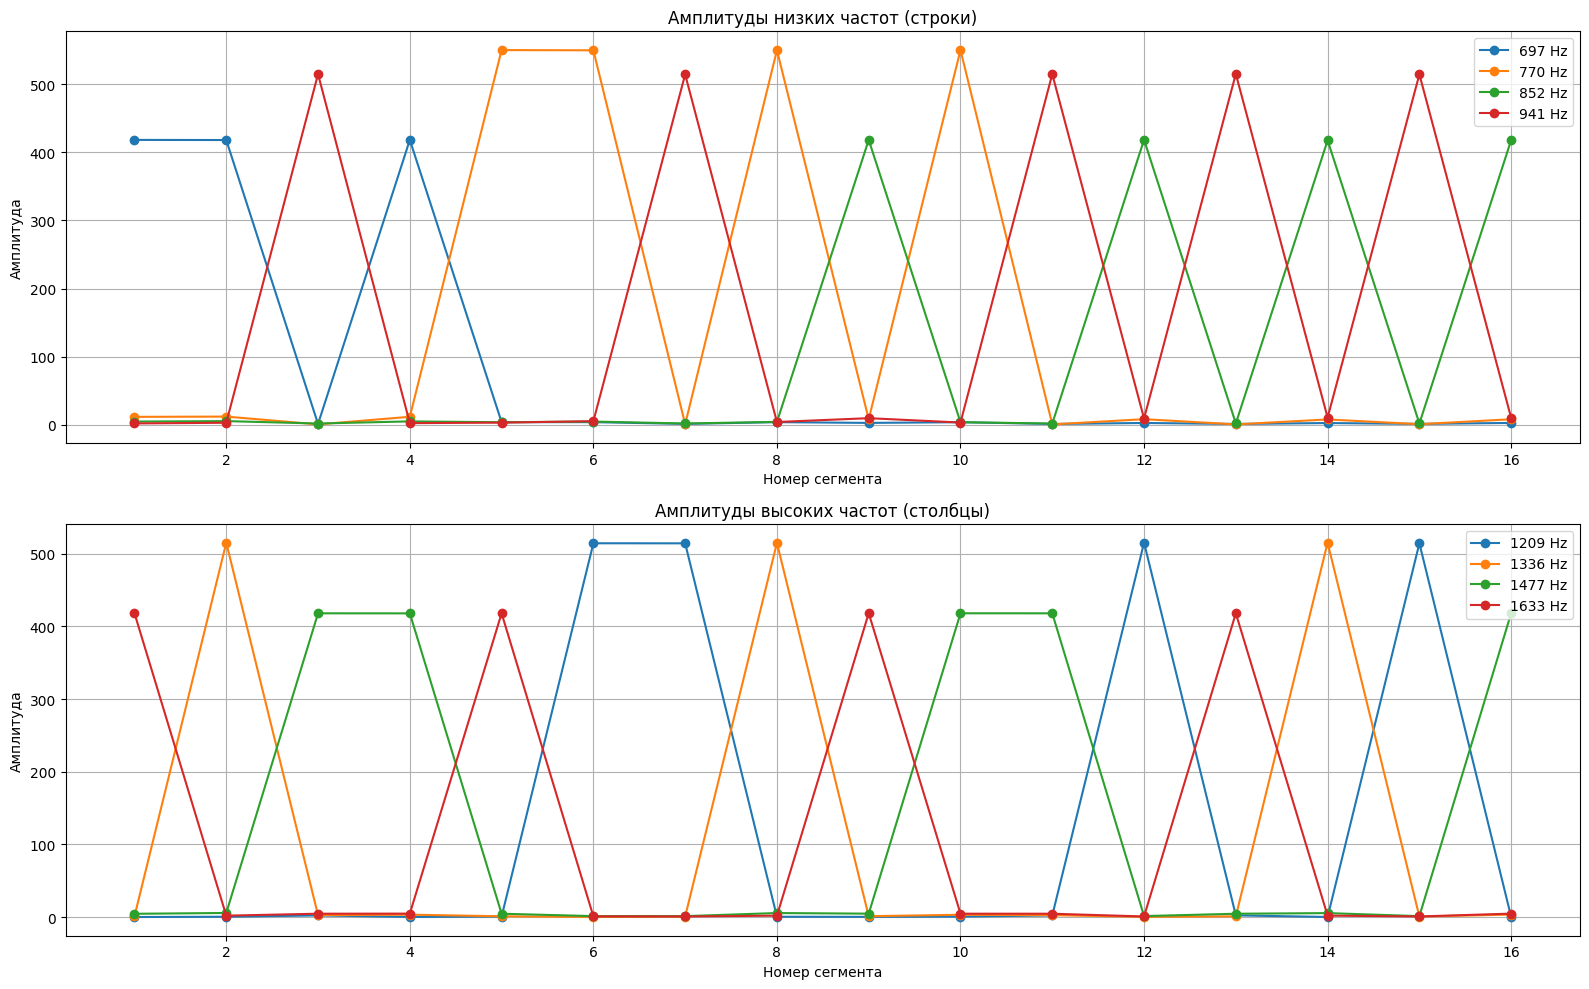

In [10]:
# Визуализация амплитуд для всех сегментов
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Низкие частоты
axes[0].plot(range(1, num_segments + 1), [mags[0] for mags in all_low_mags], 'o-', label=f'{low_freqs[0]} Hz')
axes[0].plot(range(1, num_segments + 1), [mags[1] for mags in all_low_mags], 'o-', label=f'{low_freqs[1]} Hz')
axes[0].plot(range(1, num_segments + 1), [mags[2] for mags in all_low_mags], 'o-', label=f'{low_freqs[2]} Hz')
axes[0].plot(range(1, num_segments + 1), [mags[3] for mags in all_low_mags], 'o-', label=f'{low_freqs[3]} Hz')
axes[0].set_xlabel('Номер сегмента')
axes[0].set_ylabel('Амплитуда')
axes[0].set_title('Амплитуды низких частот (строки)')
axes[0].legend()
axes[0].grid(True)

# Высокие частоты
axes[1].plot(range(1, num_segments + 1), [mags[0] for mags in all_high_mags], 'o-', label=f'{high_freqs[0]} Hz')
axes[1].plot(range(1, num_segments + 1), [mags[1] for mags in all_high_mags], 'o-', label=f'{high_freqs[1]} Hz')
axes[1].plot(range(1, num_segments + 1), [mags[2] for mags in all_high_mags], 'o-', label=f'{high_freqs[2]} Hz')
axes[1].plot(range(1, num_segments + 1), [mags[3] for mags in all_high_mags], 'o-', label=f'{high_freqs[3]} Hz')
axes[1].set_xlabel('Номер сегмента')
axes[1].set_ylabel('Амплитуда')
axes[1].set_title('Амплитуды высоких частот (столбцы)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## Детальный анализ одного сегмента


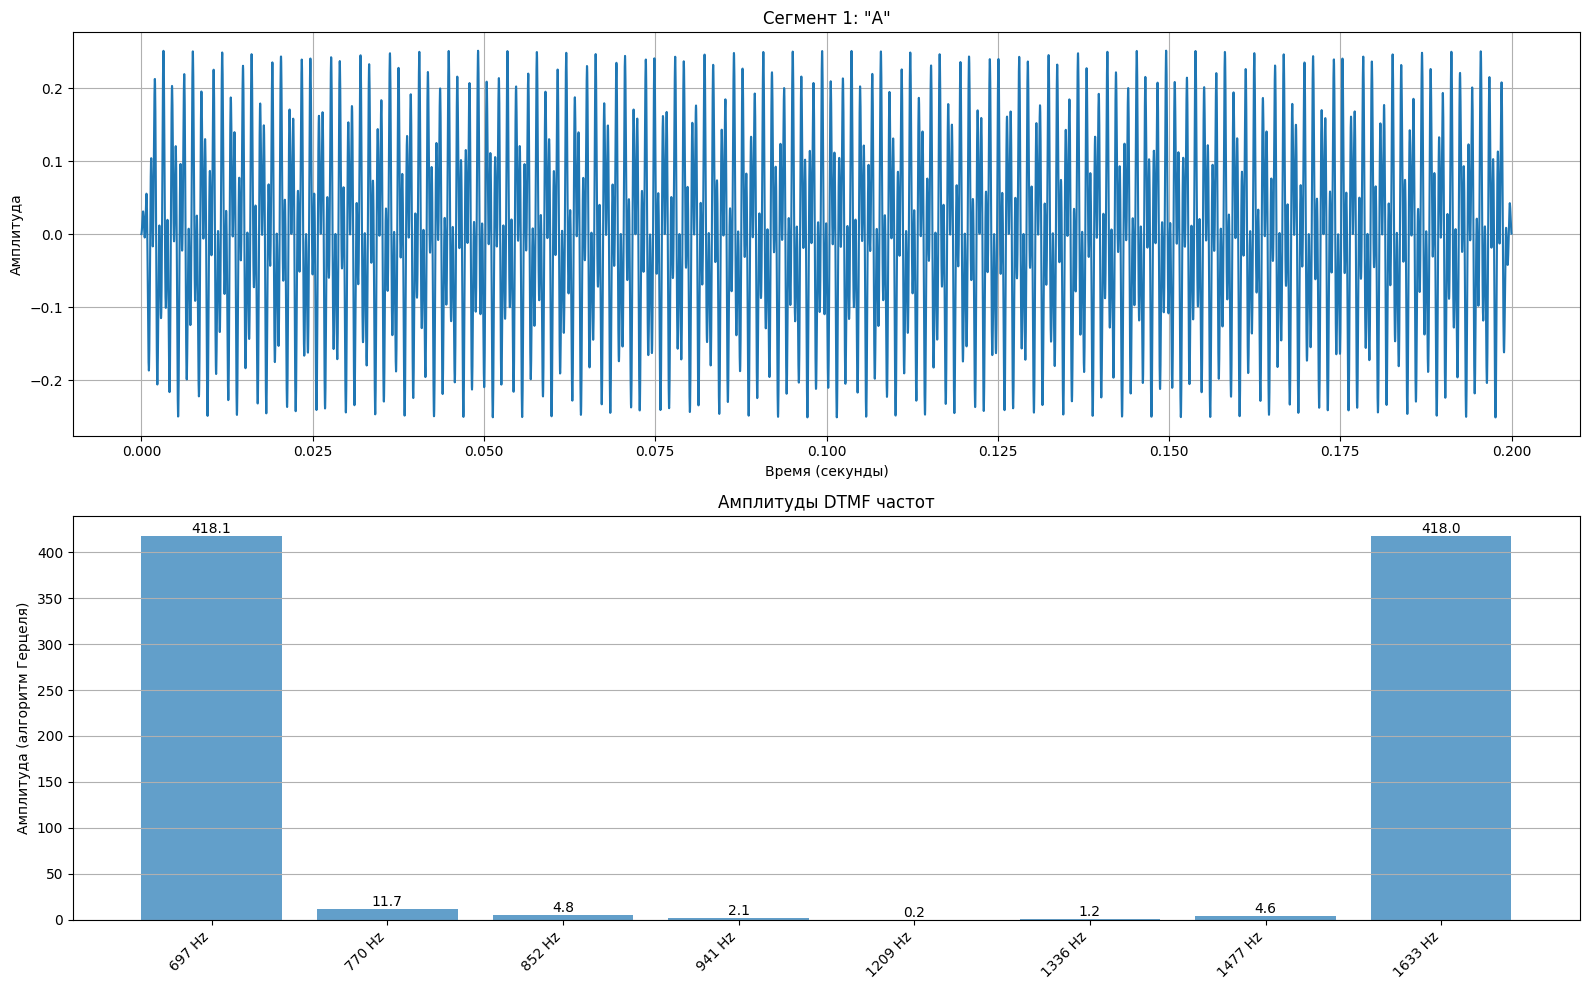

Декодированный символ: 'A'

Амплитуды низких частот:
   697 Hz: 418.06
   770 Hz: 11.69
   852 Hz: 4.80
   941 Hz: 2.05

Амплитуды высоких частот:
  1209 Hz: 0.18
  1336 Hz: 1.15
  1477 Hz: 4.61
  1633 Hz: 418.03


In [ ]:
segment_idx = 0
for i, s in enumerate(decoded_sequence):
    if s:
        segment_idx = i
        break

start_idx = segment_idx * segment_samples
end_idx = start_idx + element_samples
element_segment = x[start_idx:end_idx]

all_freqs = low_freqs + high_freqs
magnitudes = [goertzel(element_segment, f, Fd, N) for f in all_freqs]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Временная область
time_seg = np.arange(len(element_segment)) / Fd
axes[0].plot(time_seg, element_segment)
axes[0].set_xlabel('Время (секунды)')
axes[0].set_ylabel('Амплитуда')
axes[0].set_title(f'Сегмент {segment_idx+1}: "{decoded_sequence[segment_idx]}"')
axes[0].grid(True)

# Частотная область (амплитуды Герцеля)
freq_labels = [f'{f} Hz' for f in all_freqs]
x_pos = np.arange(len(all_freqs))
axes[1].bar(x_pos, magnitudes, alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(freq_labels, rotation=45, ha='right')
axes[1].set_ylabel('Амплитуда (алгоритм Герцеля)')
axes[1].set_title('Амплитуды DTMF частот')
axes[1].grid(True, axis='y')

# Подписи значений
for i, mag in enumerate(magnitudes):
    axes[1].text(i, mag, f'{mag:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Декодированный символ: '{decoded_sequence[segment_idx]}'")
print(f"\nАмплитуды низких частот:")
for i, f in enumerate(low_freqs):
    print(f"  {f:4d} Hz: {magnitudes[i]:.2f}")
print(f"\nАмплитуды высоких частот:")
for i, f in enumerate(high_freqs):
    print(f"  {f:4d} Hz: {magnitudes[i+4]:.2f}")


## Пояснение к результатам

**Что означают значения в скобках?**

Числа в скобках (например, 418.1 и 418.0) — это **амплитуды спектральных компонент**, вычисленные алгоритмом Герцеля для обнаруженных DTMF частот.

- **Чем больше значение**, тем сильнее присутствие данной частоты в сигнале
- Эти значения используются для **детекции** того, какая именно комбинация частот присутствует в сигнале
- Алгоритм находит максимальные амплитуды среди низких (697, 770, 852, 941 Hz) и высоких (1209, 1336, 1477, 1633 Hz) частот
- По комбинации обнаруженных частот определяется соответствующий символ (цифра или управляющая клавиша)

**Пример:** Для символа 'A' обнаружены частоты 697 Hz (амплитуда 418.1) и 1633 Hz (амплитуда 418.0), что соответствует комбинации (697, 1633) → 'A' в таблице DTMF.

## Итоговый результат


In [14]:
print("=" * 60)
print("РЕЗУЛЬТАТ ДЕКОДИРОВАНИЯ DTMF СИГНАЛА")
print("=" * 60)
print(f"\nКоличество сегментов: {num_segments}")
print(f"Восстановленная последовательность:")
print(f"  {''.join([s if s else '?' for s in decoded_sequence])}")
print(f"\nДетализация:")
for i, symbol in enumerate(decoded_sequence):
    if symbol:
        low_idx = np.argmax(all_low_mags[i])
        high_idx = np.argmax(all_high_mags[i])
        detected_low_freq = low_freqs[low_idx]
        detected_high_freq = high_freqs[high_idx]
        low_mag = all_low_mags[i][low_idx]
        high_mag = all_high_mags[i][high_idx]
        print(f"  Сегмент {i+1:2d}: '{symbol}' "
              f"(низкая: {detected_low_freq} Hz: {low_mag:.1f}, "
              f"высокая: {detected_high_freq} Hz: {high_mag:.1f})")
    else:
        print(f"  Сегмент {i+1:2d}: не распознан")
print("=" * 60)


РЕЗУЛЬТАТ ДЕКОДИРОВАНИЯ DTMF СИГНАЛА

Количество сегментов: 16
Восстановленная последовательность:
  A2#3B4*5C6#7D8*9

Детализация:
  Сегмент  1: 'A' (низкая: 697 Hz: 418.1, высокая: 1633 Hz: 418.0)
  Сегмент  2: '2' (низкая: 697 Hz: 417.9, высокая: 1336 Hz: 515.0)
  Сегмент  3: '#' (низкая: 941 Hz: 514.6, высокая: 1477 Hz: 417.9)
  Сегмент  4: '3' (низкая: 697 Hz: 418.0, высокая: 1477 Hz: 417.8)
  Сегмент  5: 'B' (низкая: 770 Hz: 549.8, высокая: 1633 Hz: 417.9)
  Сегмент  6: '4' (низкая: 770 Hz: 549.5, высокая: 1209 Hz: 514.2)
  Сегмент  7: '*' (низкая: 941 Hz: 514.2, высокая: 1209 Hz: 514.1)
  Сегмент  8: '5' (низкая: 770 Hz: 549.6, высокая: 1336 Hz: 514.7)
  Сегмент  9: 'C' (низкая: 852 Hz: 418.0, высокая: 1633 Hz: 418.0)
  Сегмент 10: '6' (низкая: 770 Hz: 549.9, высокая: 1477 Hz: 417.9)
  Сегмент 11: '#' (низкая: 941 Hz: 514.6, высокая: 1477 Hz: 417.9)
  Сегмент 12: '7' (низкая: 852 Hz: 418.3, высокая: 1209 Hz: 515.0)
  Сегмент 13: 'D' (низкая: 941 Hz: 514.9, высокая: 1633 Hz: 417.